<a href="https://colab.research.google.com/github/mohamedelziat50/Diabetes-Disease-Classification-MIU/blob/norhan/Diabetes_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Project - Machine Learning Pipeline on a Diabetes Disease Classification Dataset

---

Data we're working on:

**Full Dataset**: (`diabetes_prediction_dataset.csv`) - 100k examples

---

To understand the meaning of every feature:
1. Kaggle Competition Link (Join the competition aswell): Link Here Later
2. Go the `Data` section
3. You'll find an explaination in the description (el mafrood yaani)

## Import The Neccesary Libraries

In [ ]:
!pip install pyswarm

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,learning_curve,GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, accuracy_score,
                             ConfusionMatrixDisplay)

# Logistic Regression Related
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC, LinearSVC
from pyswarm import pso
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV

## Read The Dataset
Upload through files in colab.

Note: The target variable for prediction is `diabetes`

0 (Non-diabetic), 1 (Diabetic)

In [ ]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

## Check Dataset Information & Examples
 Column datatypes and number of non null values

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


Dataset's shape:
- 100,000 examples
- 9 features - including target feature

In [ ]:
print("Dataset's shape:", df.shape)

Dataset's shape: (100000, 9)


Identify numerical & categorical columns

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Number of numerical features: {len(numerical_cols)}")
print(f"Number of categorical features: {len(categorical_cols)}: ({list(categorical_cols)})")

Number of numerical features: 7
Number of categorical features: 2: (['gender', 'smoking_history'])


Display first 10 rows using pandas

In [ ]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


## A. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of analyzing a dataset to summarize its main characteristics, often using visualizations. The goal of EDA is to understand the structure, patterns, and relationships in the data before applying any modeling or feature engineering. It helps identify trends, outliers, missing values, and potential issues that could affect model performance.

---

***Not Implemented Yet, Only Checked For Data Imbalance + In Preproccesing Section Detected Numercal Outliers after removing duplicates later, reason is stated there. You should see categorcal outliers here incase aswell.***

**Categorical Feature Distribution**

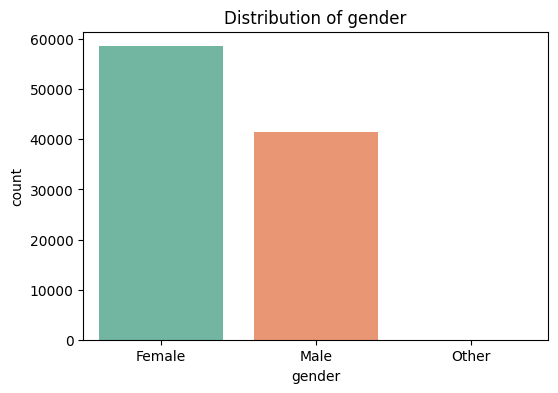

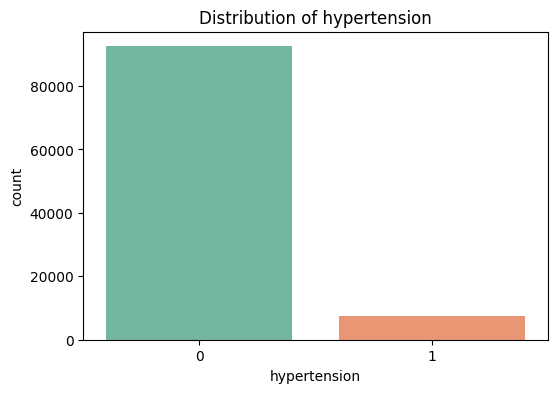

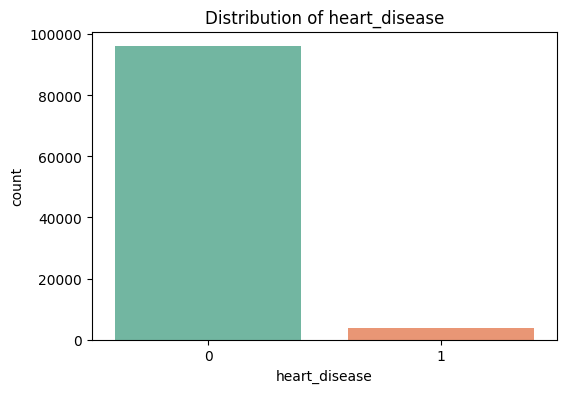

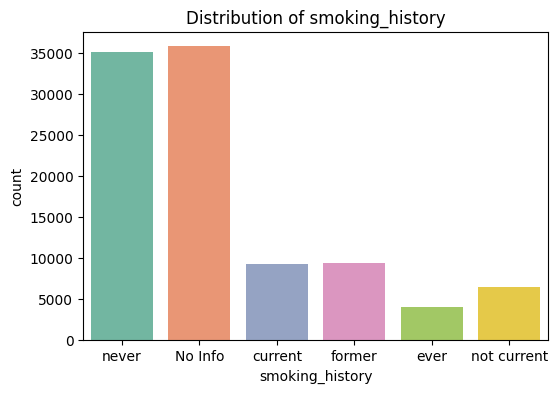

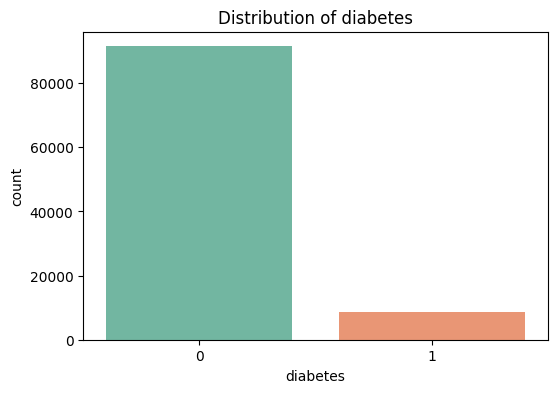

In [ ]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'smoking_history', 'diabetes']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue=col, data=df, palette="Set2", legend=False)
    plt.title(f"Distribution of {col}")
    plt.show()


**Numeric Feature Distribution**

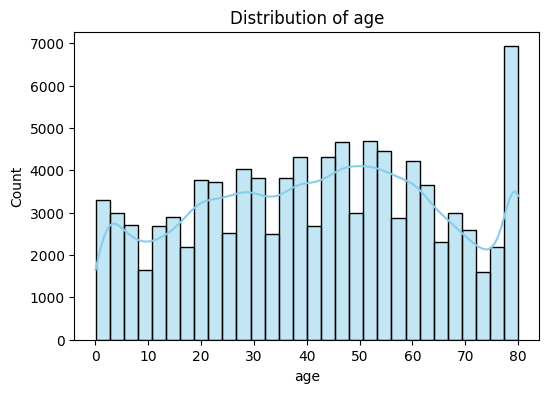

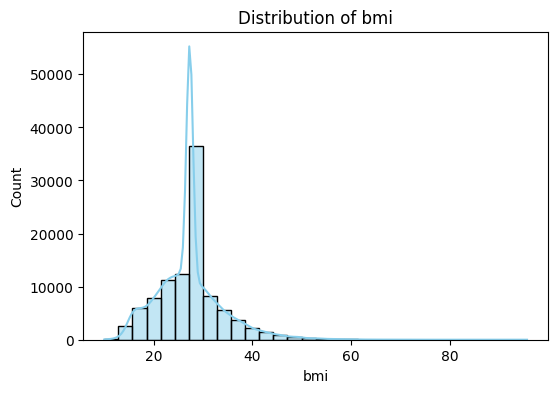

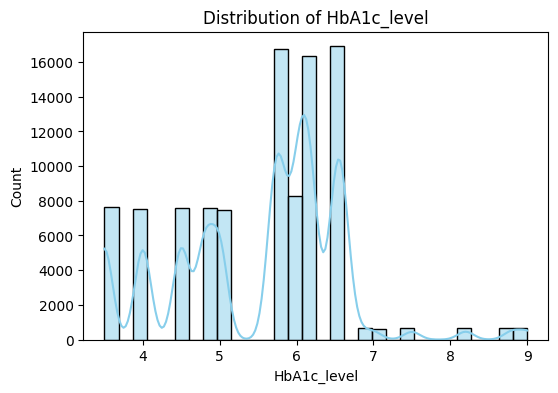

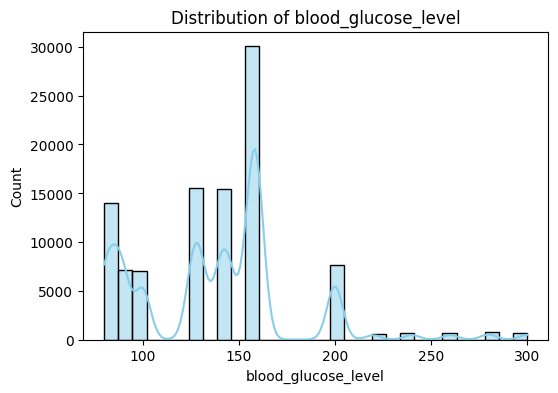

In [ ]:
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()


**Correlation Analysis**

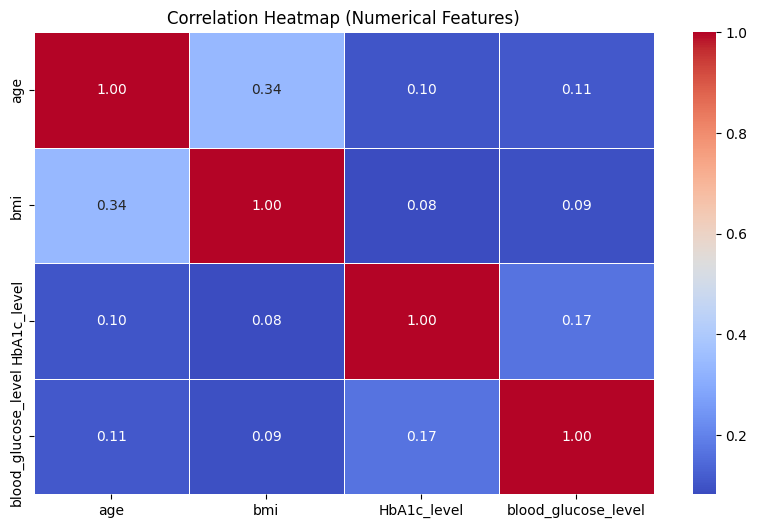

In [ ]:
plt.figure(figsize=(10, 6))

corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

**Feature Relationships**

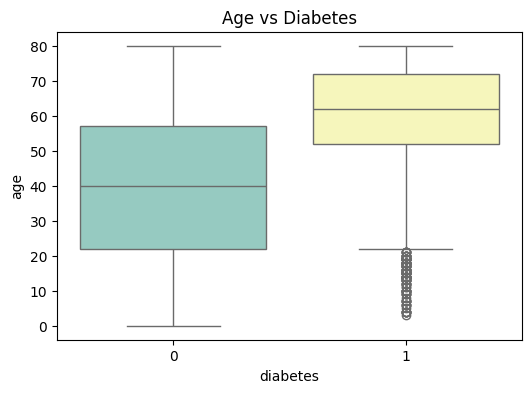

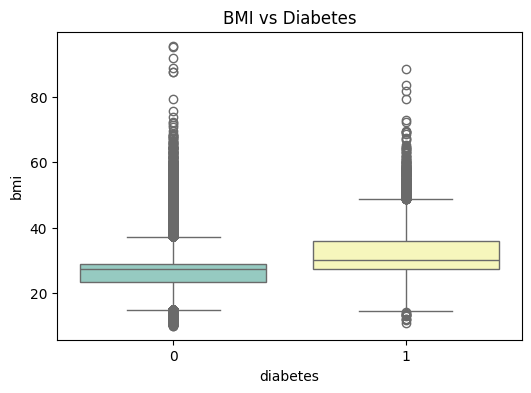

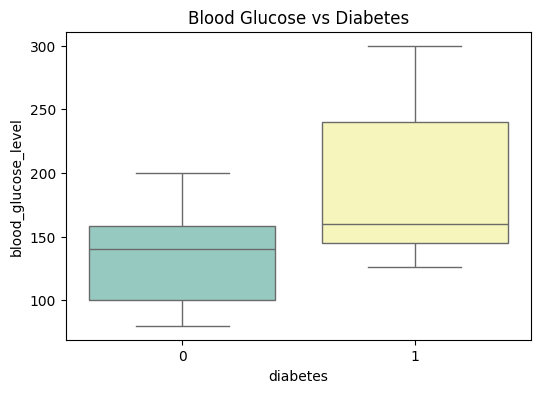

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="diabetes", y="age", data=df, hue="diabetes", palette="Set3", legend=False)
plt.title("Age vs Diabetes")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="diabetes", y="bmi", data=df, hue="diabetes", palette="Set3", legend=False)
plt.title("BMI vs Diabetes")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="diabetes", y="blood_glucose_level", data=df, hue="diabetes", palette="Set3", legend=False)
plt.title("Blood Glucose vs Diabetes")
plt.show()


**Smoking History vs Diabetes**

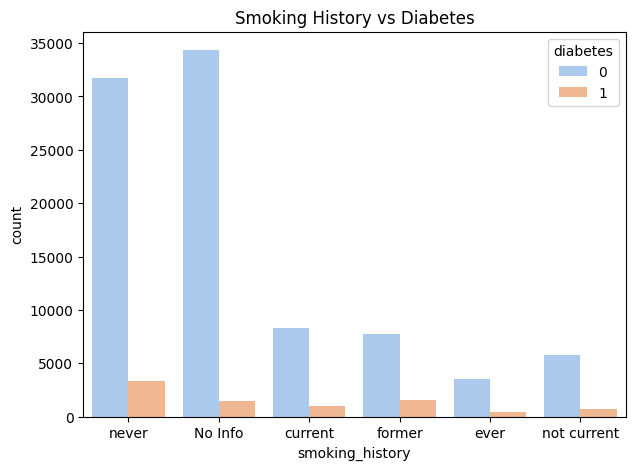

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x="smoking_history", hue="diabetes", data=df, palette="pastel")
plt.title("Smoking History vs Diabetes")
plt.show()


### Check For Data Imbalance

In [ ]:
print(df['diabetes'].value_counts())
print(df['diabetes'].value_counts(normalize=True) * 100)

diabetes
0    91500
1     8500
Name: count, dtype: int64
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


Showing The number of diabteics (1) and non diabetics (0) from the classes To the be balanced using SMOTE

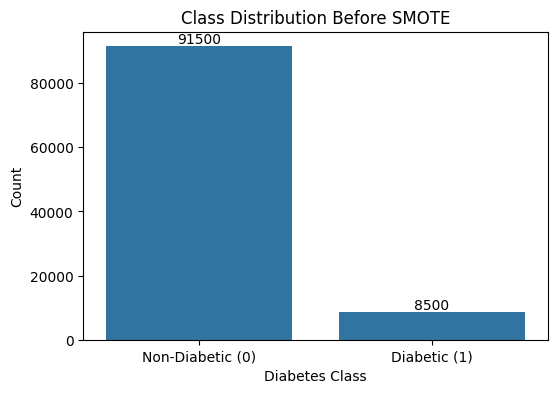

In [ ]:
# BEFORE SMOTE (original data)

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="diabetes")

plt.title("Class Distribution Before SMOTE")
plt.xlabel("Diabetes Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Diabetic (0)", "Diabetic (1)"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

The distribution of the target variable (diabetes) is:

Class 0 (Non-diabetic): **91.18%**

Class 1 (Diabetic): **8.82%**

---

Conclusion

The dataset is highly imbalanced, as one class significantly dominates the other.

Using accuracy alone may be misleading, so evaluation metrics such as Precision, Recall, and F1-score should be considered.

## B. Data Preprocessing & Cleaning

### 1. Detect Missing Values
Display a table representing nulls (feature -> corresponding records with nulls)

- .isnull(): Returns a boolean mask of True & False values
- .sum(): Counts the True values in each column/feature

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


Table shows that there are no features with nulls.

### 2. Handle Unique & Identical Value Columns
Count the number of unique values in each column to check whether:
- The values are all unique (no pattern to be found in the data)
- The values are all the same (not useful - identical)

nunique(): counts the number of unique non-null values

In [ ]:
df.nunique()

,0
gender,3
age,102
hypertension,2
heart_disease,2
smoking_history,6
bmi,4247
HbA1c_level,18
blood_glucose_level,18
diabetes,2


### 3. Handle Duplicate Values
.duplicated(): used to find duplicate rows

np.int64(0) indicates that no duplicate values exist, so no duplicates to be removed

In [ ]:
print("Duplicated rows (before removal):", df.duplicated().sum())
print("DataFrame shape:", df.shape)
df.drop_duplicates(inplace=True)

print("Duplicated rows (after removal):", df.duplicated().sum())
print("New DataFrame shape:", df.shape)

# Drop rows where any value is NaN (only 1 row affected)
print("\nNull values before drop:", df.isnull().sum().sum())
df.dropna(inplace=True)
print("Null values after drop:", df.isnull().sum().sum())
print("Final DataFrame shape:", df.shape)

Duplicated rows (before removal): 3854
DataFrame shape: (100000, 9)
Duplicated rows (after removal): 0
New DataFrame shape: (96146, 9)

Null values before drop: 0
Null values after drop: 0
Final DataFrame shape: (96146, 9)


In [ ]:
# Replace "No Info" in smoking_history with the mode (most frequent real category)
smoking_mode = df[df["smoking_history"] != "No Info"]["smoking_history"].mode()[0]
print("Imputing 'No Info' with:", smoking_mode)

df["smoking_history"] = df["smoking_history"].replace("No Info", smoking_mode)

print("\nsmoke_history value counts after imputation:")
print(df["smoking_history"].value_counts())

Imputing 'No Info' with: never

smoke_history value counts after imputation:
smoking_history
never          67285
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


### 4. Handle Garbage Values

Garbage values: incorrect, unexpected data

Identifying garbage values in `string` objects (simply eyeballing the value & noticing if anything is out of place or unexpected.)

In [ ]:
for feature in df.select_dtypes(include = "object").columns:
    print("=" * 10, "Feature:", feature, "=" * 10)
    print(df[feature].value_counts()) # Displays a value and it's count
    print() # New Line

========== Feature: gender ==========
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

========== Feature: smoking_history ==========
smoking_history
never          67285
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64



### 5. Detect Outliers (Numerical)
.describe(): Descriptive statistics to understand more about the data

---
Important Note:
Why Detect Outliers **After** Removing Duplicates?

Outlier detection is performed after removing duplicates to avoid distorted statistics. Duplicate records can bias the mean and quartiles, leading to incorrect identification of outliers. Removing them first ensures more accurate and reliable results.

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


We identified the columns that have outliers through:
- Difference between `75%` and `max` is SIGNIFICANT (Higher Outliers)
- Difference between `50%` (median) and `mean` is SIGNIFICANT
- Difference between `25%` and `min` is SIGNIFICANT (Lower Outliers)

---

Features with possible outliers (all with **right skew**):
*   **`bmi`** - (STRONG HIGH OUTLIERS) ~96 may be extreme for most datasets.
*   **`HbA1c_level`** - (MILD HIGH OUTLIERS) values near 9 are relatively high medically.
*   **`blood_glucose_level`** - (STRONG HIGH OUTLIERS) Vvlues like 300 are very high, but in somecases can actually be real in extreme case.

Why **`age`** isn't considered an outlier for near 0 values?

A baby can have diabetes. While very rare, infants can develop neonatal diabetes within the first six months of life, usually caused by a genetic mutation rather than autoimmune factors. -> **Thus age near 0 is valid**

---

**Important Note**:
Dataset mainly has **upper-end outliers**, not lower ones.
This is **common in medical data** (extreme cases).

Descripitive statistics for `string` values aswell

In [ ]:
df.describe(include = "object")

,gender,smoking_history
count,96146,96146
unique,3,5
top,Female,never
freq,56161,67285


#### Visualization Function
Created a visualization function to avoid repeated code, just specify type of diagram needed to be displayed.

Assumes 18 Features, So keep that in mind! (not generic)

Matplotlib Syntax:
- plt.subplot(2, 3, i)  # 2 rows, 3 columns, current index

In [ ]:
def visualize_diagram(diagram_name):
    # Intialize rows and columns (6 rows with 3 plots per row)
    rows = 6
    columns = 3

    # Create the big plot with specific dimensions
    plt.figure(figsize=(5 * columns, 4 * rows))

    # Iterate over the features & create the histograms
    for i, col in enumerate(numeric_columns):
        plt.subplot(rows, columns, i + 1) # +1 because Matplotlib starts from index 1 in the plots
        if diagram_name == "Histogram":
            sns.histplot(data=df, x=col)
        elif diagram_name == "Boxplot":
            sns.boxplot(data=df, x=col)

    plt.tight_layout()
    plt.show()

#### Histogram Visualization
Histogram to understand data distribution (numeric columns)

In [ ]:
# Select numeric columns - returns a list (not dateframe)
numeric_columns = df.select_dtypes(include="number").columns

# Store the numeric columns length (18 features)
numeric_columns_length = len(numeric_columns)

print("Number of numeric columns/features:", numeric_columns_length)

Number of numeric columns/features: 7


Some distributions appear to be 'skewed' because of outliers.

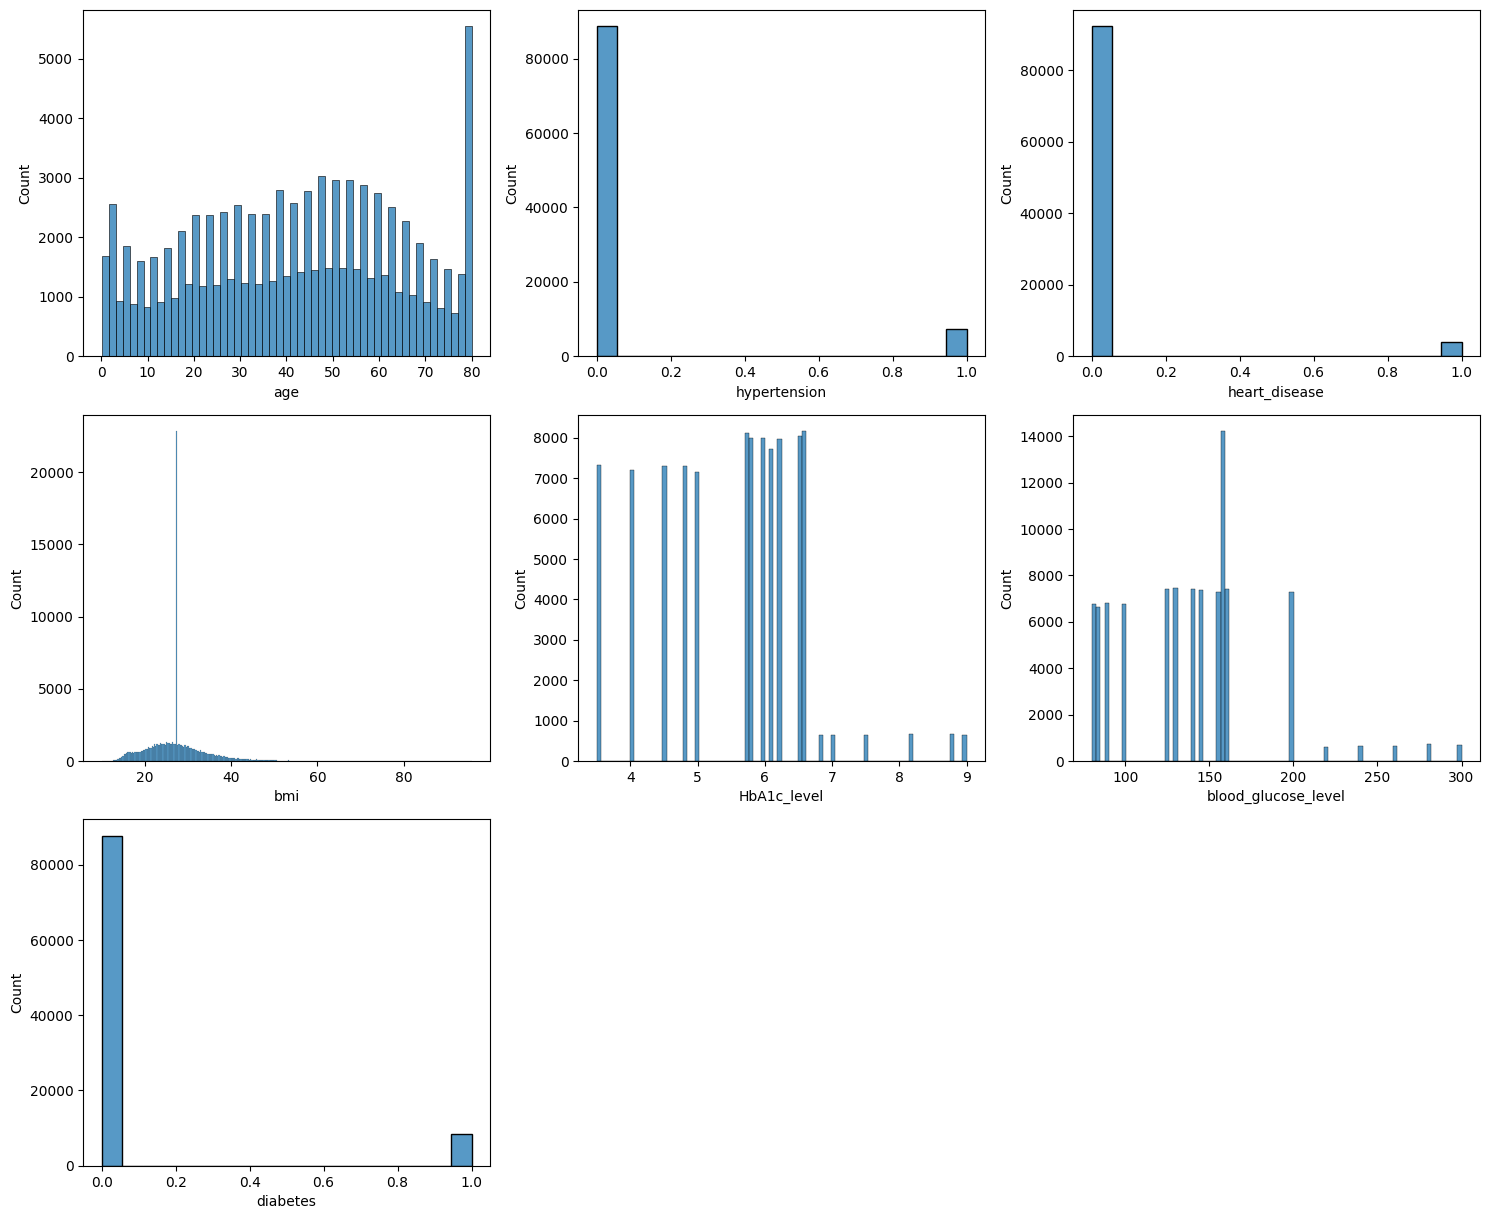

In [ ]:
visualize_diagram("Histogram")

#### Boxplot Visualization
To identify outliers visually through the whiskers

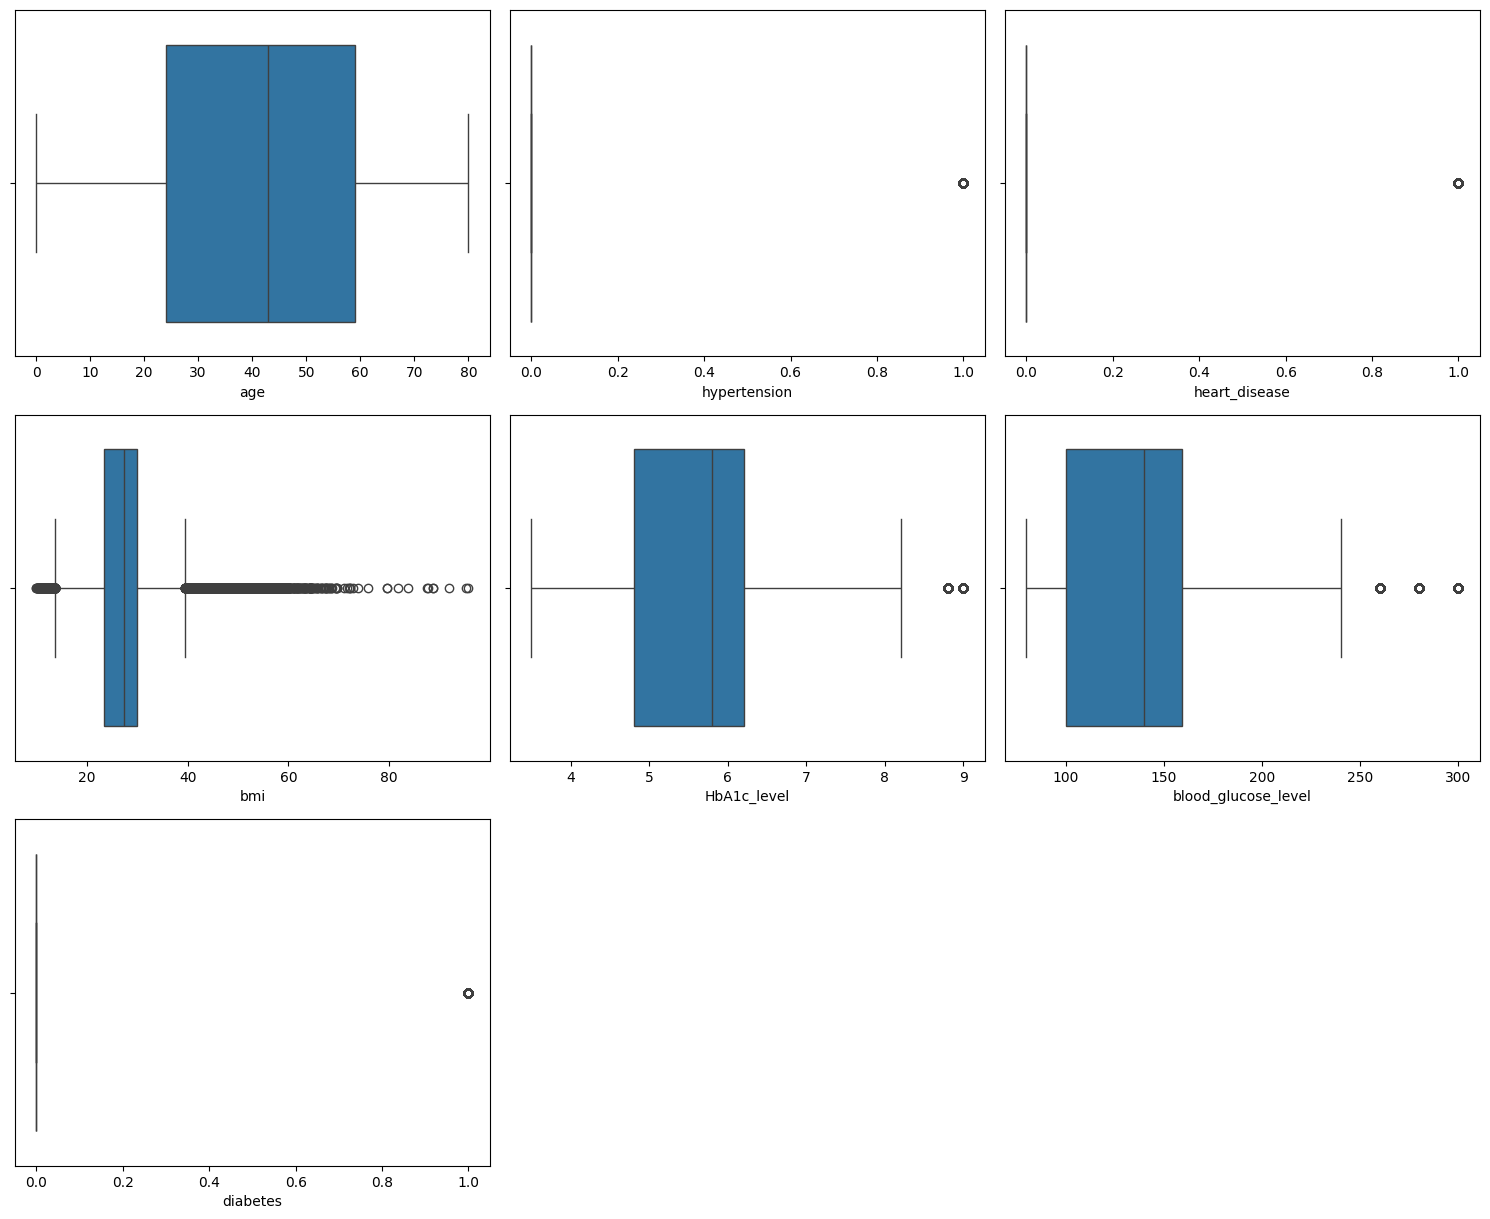

In [ ]:
visualize_diagram("Boxplot")

No `undefined` values or anything out of place, only hesitant about `Other` in the `gender` feature. (msh project bas walahi)

### 6. Handle Outliers (Numerical )

Outlier method used: **Interquartile Range (IQR)** - for `numerical` columns

`Clipping`: replace outliers (anything outside the range) with the nearest acceptable value

Outliers do not always mean bad data. In this dataset, many outliers represent rare but valid cases. Since this is a classification problem, extreme values usually have less impact than in regression problems. Therefore, we only applied outlier handling to columns that naturally have a wide range of values, and we did so carefully without removing data.

---

***NOT APPLIED YET, UNTILL WE UNDERSTAND MORE ABOUT THE DATA & EDA***, uncomment later to use if needed




*  Age: No significant outliers → kept as is , becuase age is obviously highly related to having diabetes
*  Hypertension & Heart Disease: Binary (0/1) → no outliers
*  BMI: Has high outliers, but medically valid, SO IT IS WHAT MAY BE AN OUTLIER , HANSHOF SAWA
*   Other Features: Few outliers (very minimal) → ignored because minimal of like 2 or 3 outliers in the whole dataset






In [ ]:
# IQR Function that returns a 'clipped' column
def outliers_iqr(df, column):
    print("=" * 15, column, "=" * 15)

    # Get the required percentiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    print("Q1:", Q1)
    print("Q3:", Q3)

    # Difference Between Both Percentiles!
    IQR = Q3 - Q1

    print("IQR:", IQR)

    # 2 Thresholds, anything outside of this range is considered an outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    # `Clipping`: replace outliers (anything outside the range) with the nearest acceptable value
    return df[column].clip(lower_bound, upper_bound)


#### Apply IQR function to the numercal columns containing outliers

Apply IQR (Shows the lower & upper bounds)

Display the value count in each column after IQR

In [ ]:
# Cap BMI outliers using IQR before splitting
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"BMI bounds — Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f}")
print(f"BMI before capping — Min: {df['bmi'].min():.2f}, Max: {df['bmi'].max():.2f}")

df["bmi"] = df["bmi"].clip(lower_bound, upper_bound)

print(f"BMI after capping  — Min: {df['bmi'].min():.2f}, Max: {df['bmi'].max():.2f}")

BMI bounds — Lower: 13.71, Upper: 39.55
BMI before capping — Min: 10.01, Max: 95.69
BMI after capping  — Min: 13.71, Max: 39.55


### C. Final Visualization - After Preprocessing  
Double check visualziation after preprocessing & handlng outliers

In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.030939,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,5.920013,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,13.710000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,39.550000,9.000000,300.000000,1.000000


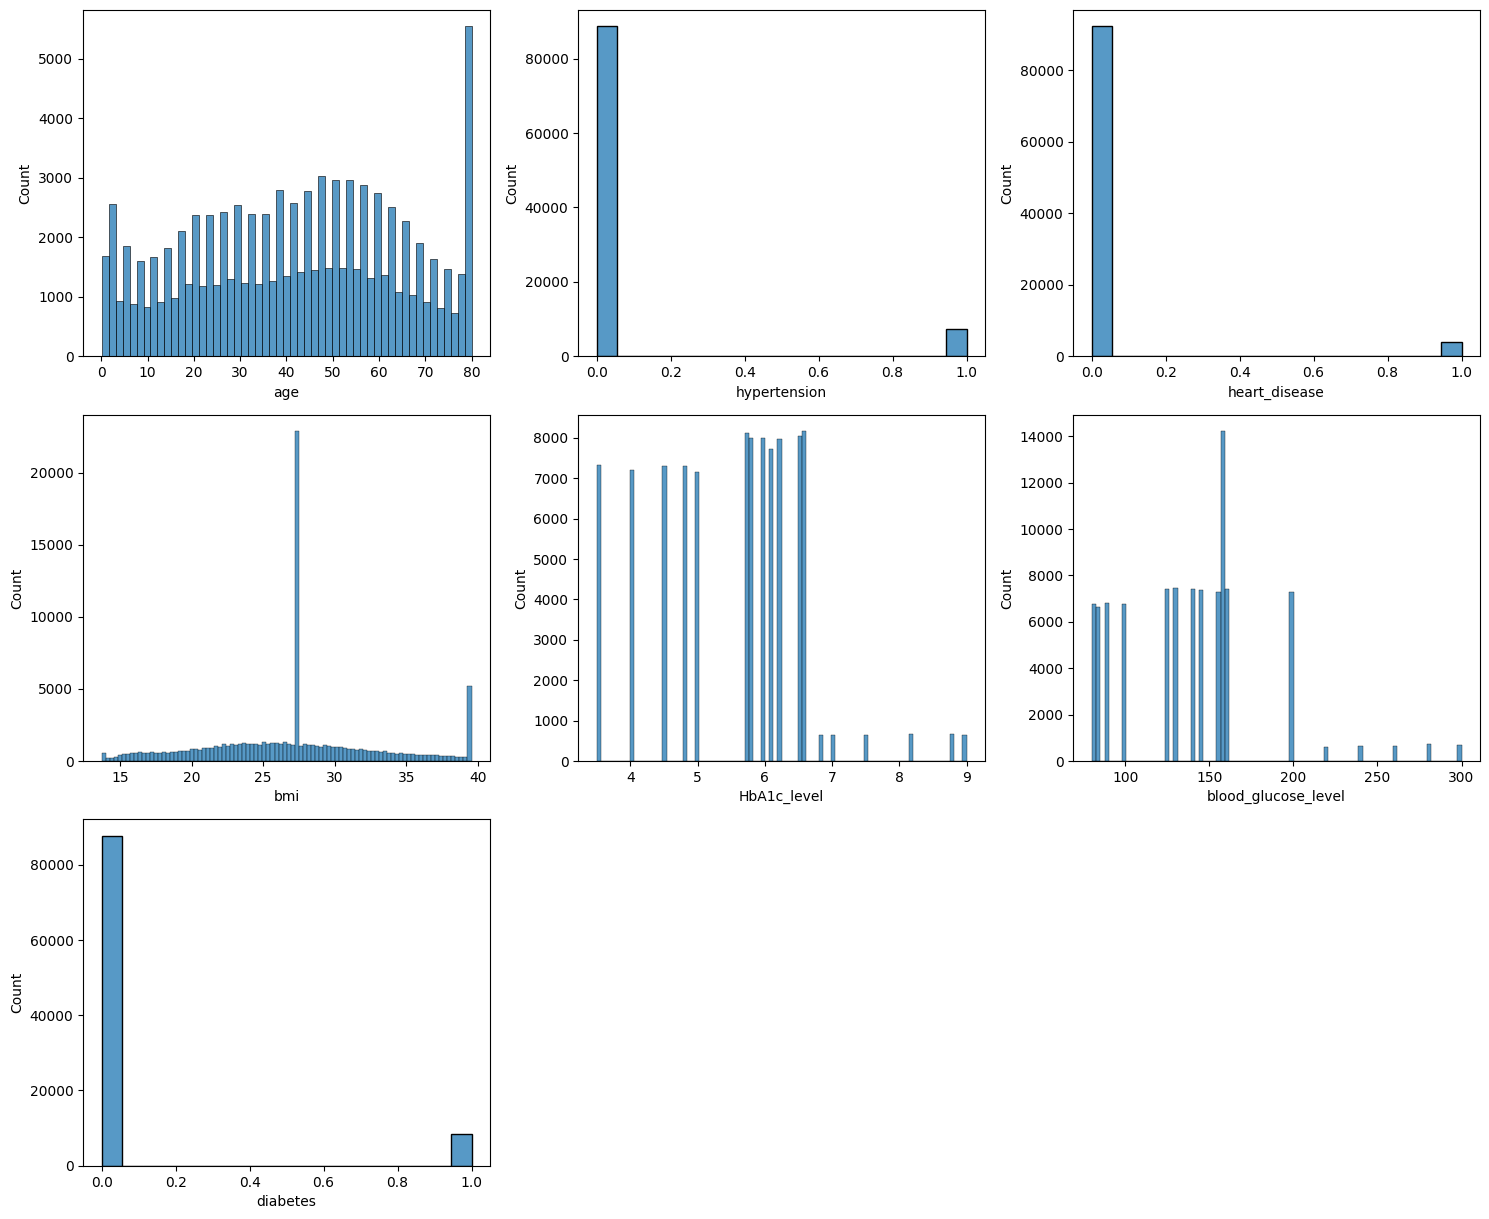

In [ ]:
visualize_diagram("Histogram")

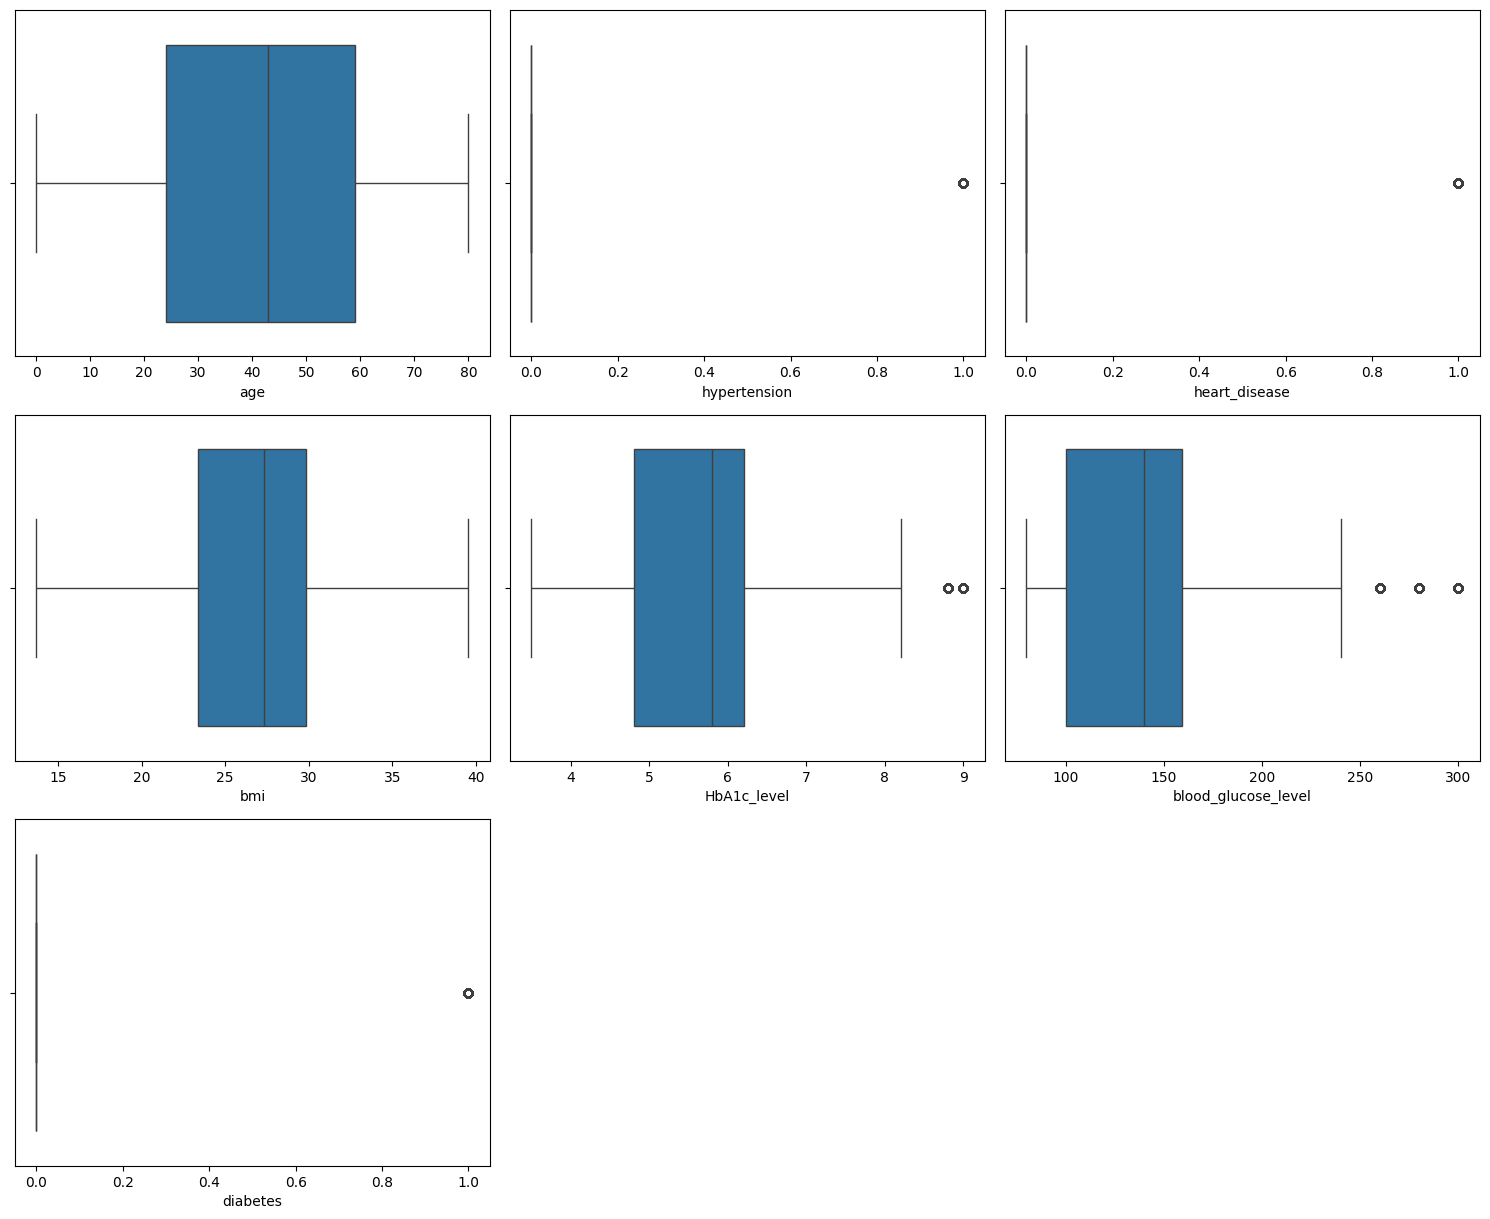

In [ ]:
visualize_diagram("Boxplot")

Dividing BMI into discrete classes

Splitting the training and test , so scaling and encoding so the model doesnt memorize them

In [ ]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (96146, 8)
Target shape: (96146,)


In [ ]:
# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: split temporary data into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (67302, 8) (67302,)
Validation set: (14422, 8) (14422,)
Test set: (14422, 8) (14422,)


# **Encoding Numerical Features and Normalizing categorical features**

# Feature Processing & Balancing

In [ ]:
# Preprocessing: Encoding + Scaling

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Separate column types
categorical_cols = X_train.select_dtypes(include=["object"]).columns
numerical_cols = X_train.select_dtypes(exclude=["object"]).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# Fit only on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)

Train shape: (67302, 14)
Validation shape: (14422, 14)
Test shape: (14422, 14)
X_val_processed: (14422, 14)
X_test_processed: (14422, 14)


we make the smote only on training data not to fit the testung data which leads to overfitting

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.7, random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())
print("X_train_smote:", X_train_smote.shape)

Before SMOTE: diabetes
0    61365
1     5937
Name: count, dtype: int64
After SMOTE: diabetes
0    61365
1    42955
Name: count, dtype: int64
X_train_smote: (104320, 14)


# PCA

In [ ]:
from scipy import sparse
from sklearn.decomposition import PCA

def to_dense(X):
    if sparse.issparse(X):
        return X.toarray()
    return X

X_train_dense = to_dense(X_train_processed)
X_val_dense = to_dense(X_val_processed)
X_test_dense = to_dense(X_test_processed)

def apply_pca(X_train_data, X_val_data, X_test_data, n_components=0.95):
    pca = PCA(n_components=n_components, random_state=42)

    X_train_pca = pca.fit_transform(X_train_data)
    X_val_pca = pca.transform(X_val_data)
    X_test_pca = pca.transform(X_test_data)

    print("Original features:", X_train_data.shape[1])
    print("PCA features:", X_train_pca.shape[1])
    print("Explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

    return X_train_pca, X_val_pca, X_test_pca, pca

X_train_pca, X_val_pca, X_test_pca, pca_model = apply_pca(
    X_train_dense,
    X_val_dense,
    X_test_dense,
    n_components=0.95
)

Original features: 14
PCA features: 8
Explained variance: 0.9692


#Evaluate Model Function

In [ ]:
def evaluate_model(model_name, model, X_train_data, y_train_data, X_val_data, y_val_data, X_test_data, y_test_data):
    # Train model
    model.fit(X_train_data, y_train_data)

    # Training prediction
    y_train_pred = model.predict(X_train_data)

    train_accuracy = accuracy_score(y_train_data, y_train_pred)
    train_precision = precision_score(y_train_data, y_train_pred)
    train_recall = recall_score(y_train_data, y_train_pred)
    train_f1 = f1_score(y_train_data, y_train_pred)

    # Validation prediction
    y_val_pred = model.predict(X_val_data)

    val_accuracy = accuracy_score(y_val_data, y_val_pred)
    val_precision = precision_score(y_val_data, y_val_pred)
    val_recall = recall_score(y_val_data, y_val_pred)
    val_f1 = f1_score(y_val_data, y_val_pred)

    # Test prediction
    y_test_pred = model.predict(X_test_data)

    test_accuracy = accuracy_score(y_test_data, y_test_pred)
    test_precision = precision_score(y_test_data, y_test_pred)
    test_recall = recall_score(y_test_data, y_test_pred)
    test_f1 = f1_score(y_test_data, y_test_pred)

    print(f"--- {model_name} Model Evaluation ---")
    summary_data = {
        'Metric': ['Accuracy', 'Precision', 'Recall/Sensitivity', 'F1 Score'],
        'Training': [f'{train_accuracy:.4f}', f'{train_precision:.4f}', f'{train_recall:.4f}', f'{train_f1:.4f}'],
        'Validation': [f'{val_accuracy:.4f}', f'{val_precision:.4f}', f'{val_recall:.4f}', f'{val_f1:.4f}'],
        'Testing': [f'{test_accuracy:.4f}', f'{test_precision:.4f}', f'{test_recall:.4f}', f'{test_f1:.4f}']
    }
    summary_df = pd.DataFrame(summary_data).set_index('Metric')
    display(summary_df)

    print(f"\n--- {model_name} Validation Classification Report ---")
    print(classification_report(y_val_data, y_val_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test_data, y_test_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy,
        "Testing Accuracy": test_accuracy,
        "Training Precision": train_precision,
        "Validation Precision": val_precision,
        "Testing Precision": test_precision,
        "Training Recall/Sensitivity": train_recall,
        "Validation Recall/Sensitivity": val_recall,
        "Testing Recall/Sensitivity": test_recall,
        "Training F1 Score": train_f1,
        "Validation F1 Score": val_f1,
        "Testing F1 Score": test_f1
    }

#Learning Curve

In [ ]:
def plot_learning_curve(model, model_name, X_train_data, y_train_data, use_stratified_cv=False):
    """
    Works for ALL models.
    - MLP: uses loss_curve_ (iteration based)
    - All others: uses learning_curve() from sklearn (training size based)

    Args:
        model: The machine learning model.
        model_name (str): Name of the model.
        X_train_data: Training features.
        y_train_data: Training target labels.
        use_stratified_cv (bool, optional): Whether to use StratifiedKFold for cross-validation. Defaults to False.
    """

    # --- MLP: use internal loss and validation scores ---
    if hasattr(model, "loss_curve_"):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        axes[0].plot(model.loss_curve_, label="Training Loss", color="blue")
        if hasattr(model, "validation_scores_") and model.validation_scores_ is not None:
            axes[0].plot(
                [1 - s for s in model.validation_scores_],
                label="Validation Loss (1 - acc)",
                color="orange",
                linestyle="--"
            )
        axes[0].set_title(f"{model_name} — Loss Curve")
        axes[0].set_xlabel("Iterations")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True)

        if hasattr(model, "validation_scores_") and model.validation_scores_ is not None:
            axes[1].plot(model.validation_scores_,
                         label="Validation Accuracy", color="green")
        axes[1].set_title(f"{model_name} — Validation Accuracy Curve")
        axes[1].set_xlabel("Iterations")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()
        axes[1].grid(True)

    # --- All other models: use sklearn's learning_curve ---
    else:
        cv_strategy = 5 # Default to 5-fold cross-validation
        if use_stratified_cv:
            # Explicitly define StratifiedKFold for cross-validation for Logistic Regression
            cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        train_sizes, train_scores, val_scores = learning_curve(
            model,
            X_train_data,
            y_train_data,
            cv=cv_strategy,
            scoring="accuracy",
            train_sizes=np.linspace(0.1, 1.0, 10)
        )

        train_mean = train_scores.mean(axis=1)
        val_mean = val_scores.mean(axis=1)

        plt.figure(figsize=(7, 5))
        plt.plot(train_sizes, train_mean, marker="o", label="Training Accuracy", color="blue")
        plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy", color="orange")
        plt.title(f"Learning Curve - {model_name}")
        plt.xlabel("Training Size")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True)

    plt.suptitle(f"{model_name} Learning Curve", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Models

## Logistic Regression

For imbalanced classification problems like diabetes prediction:

StratifiedKFold is considered standard practice
gives more stable F1/accuracy estimates
prevents training failures
makes model comparison fairer

---

'C' parameter in Logistic Regression is the **inverse of the regularization strength.**

- Smaller 'C' values (e.g., 0.001, 0.01) indicate stronger regularization. This penalizes larger coefficients more heavily, encouraging the model to use simpler solutions and potentially reducing overfitting.

- Larger 'C' values (e.g., 10, 100) indicate weaker regularization. This allows the model to fit the training data more closely, which can be beneficial if the model is underfitting, but it also increases the risk of overfitting.

---

*The following cell takes ~ 5mins*

In [ ]:
param_grid_lr = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

lr = LogisticRegression(random_state=42, max_iter=2000)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid_lr,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_train_smote, y_train_smote)

print("Best parameters for Logistic Regression:", grid_search_lr.best_params_)
print("Best CV F1 score for Logistic Regression:", round(grid_search_lr.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for Logistic Regression: {'C': 0.01, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1 score for Logistic Regression: 0.8672


Retrain Logistic Regression with best parameters

In [ ]:
best_params_lr = grid_search_lr.best_params_

lr_best = LogisticRegression(
    C=best_params_lr["C"],
    penalty=best_params_lr["penalty"],
    solver=best_params_lr["solver"],
    class_weight=best_params_lr["class_weight"],
    max_iter=2000,
    random_state=42
)

Evaluate the best Logistic Regression model

--- Logistic Regression Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.8880,0.8800,0.8855
Precision,0.8467,0.4148,0.4276
Recall/Sensitivity,0.8888,0.8759,0.8805
F1 Score,0.8672,0.5630,0.5757



--- Logistic Regression Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     13149
           1       0.41      0.88      0.56      1273

    accuracy                           0.88     14422
   macro avg       0.70      0.88      0.75     14422
weighted avg       0.94      0.88      0.90     14422



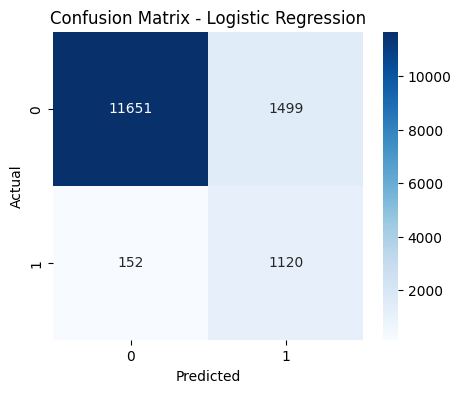

In [ ]:
lr_results = evaluate_model(
    model_name="Logistic Regression",
    model=lr_best,
    X_train_data=X_train_smote,
    y_train_data=y_train_smote,
    X_val_data=X_val_processed,
    y_val_data=y_val,
    X_test_data=X_test_processed,
    y_test_data=y_test
)

Plot learning curve for Logistic Regression

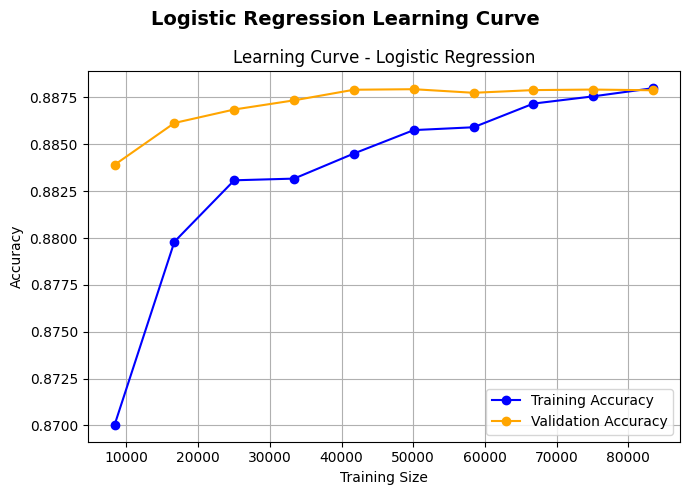

In [ ]:
plot_learning_curve(
    lr_best,
    "Logistic Regression",
    X_train_smote,
    y_train_smote,
    use_stratified_cv=True
)

## MLP - Multi Layer Perceptron

In [ ]:
param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
    "activation": ["logistic"],
    "alpha": [0.0001, 0.001],
    "learning_rate_init": [0.001, 0.0001],
    "max_iter": [500]
}

mlp = MLPClassifier(
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1 score:", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'activation': 'logistic', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 500}
Best CV F1 score: 0.8835


In [ ]:
best_params = grid_search.best_params_

mlp_best = MLPClassifier(
    hidden_layer_sizes=best_params["hidden_layer_sizes"],
    activation=best_params["activation"],
    alpha=best_params["alpha"],
    learning_rate_init=best_params["learning_rate_init"],
    max_iter=best_params["max_iter"],
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False,
    n_iter_no_change=20
)


--- MLP Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.9119,0.9129,0.9181
Precision,0.8927,0.5039,0.5213
Recall/Sensitivity,0.8935,0.8602,0.8758
F1 Score,0.8931,0.6355,0.6536



--- MLP Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.92      0.95     13149
           1       0.50      0.86      0.64      1273

    accuracy                           0.91     14422
   macro avg       0.74      0.89      0.79     14422
weighted avg       0.94      0.91      0.92     14422



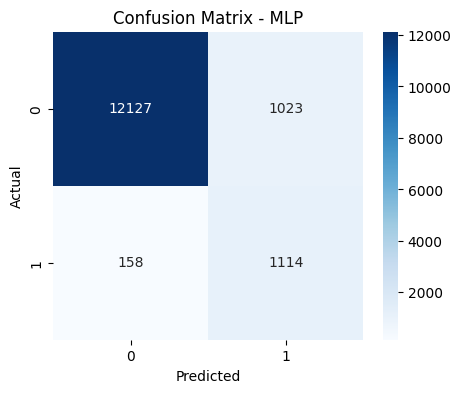

In [ ]:
mlp_results = evaluate_model(
    model_name="MLP",
    model=mlp_best,
    X_train_data=X_train_smote,
    y_train_data=y_train_smote,
    X_val_data=X_val_processed,
    y_val_data=y_val,
    X_test_data=X_test_processed,
    y_test_data=y_test
)

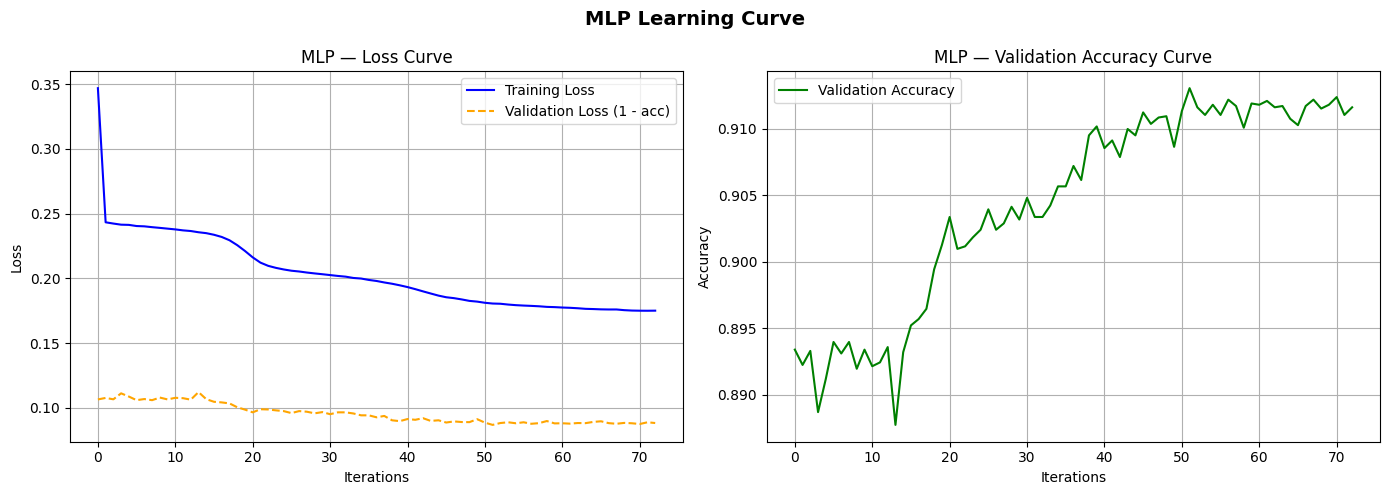

In [ ]:
# After evaluate_model is called (which trains the model internally)
plot_learning_curve(mlp_best, "MLP", X_train_smote, y_train_smote)

##  Gaussian Naive Bayes Model


Gaussian Naive Bayes was used because the diabetes dataset contains numerical continuous features after preprocessing. According to the lecture, Gaussian Naive Bayes is suitable for continuous attributes and assumes that feature values follow a Gaussian distribution.

--- Gaussian Naive Bayes Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.6195,0.6105,0.6227
Precision,0.1853,0.1803,0.1857
Recall/Sensitivity,0.9757,0.9623,0.9686
F1 Score,0.3115,0.3037,0.3117



--- Gaussian Naive Bayes Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.58      0.73     13149
           1       0.18      0.96      0.30      1273

    accuracy                           0.61     14422
   macro avg       0.59      0.77      0.52     14422
weighted avg       0.92      0.61      0.69     14422



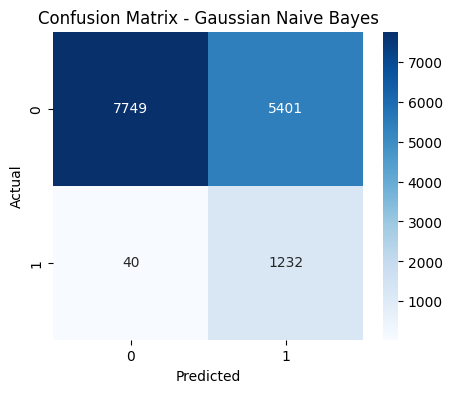

{'Model': 'Gaussian Naive Bayes',
 'Training Accuracy': 0.6195209652016285,
 'Validation Accuracy': 0.6104562473998059,
 'Testing Accuracy': 0.622729163777562,
 'Training Precision': 0.18534041464038906,
 'Validation Precision': 0.18027961736571008,
 'Testing Precision': 0.1857379767827529,
 'Training Recall/Sensitivity': 0.9757453259221829,
 'Validation Recall/Sensitivity': 0.9622937941869599,
 'Testing Recall/Sensitivity': 0.9685534591194969,
 'Training F1 Score': 0.3115102304197026,
 'Validation F1 Score': 0.3036688150718889,
 'Testing F1 Score': 0.3117014547754586}

In [ ]:
# Gaussian Naive Bayes Model WITHOUT SMOTE
nb_model = GaussianNB()

nb_results = evaluate_model(
    model_name="Gaussian Naive Bayes",
    model=nb_model,
    X_train_data=X_train_processed,
    y_train_data=y_train,
    X_val_data=X_val_processed,
    y_val_data=y_val,
    X_test_data=X_test_processed,
    y_test_data=y_test
)

nb_results

The Naive Bayes model achieved moderate accuracy and very high recall, successfully detecting most diabetic cases. However, the model generated many false positives, which reduced precision and overall performance. The learning curve indicated underfitting, suggesting that the model was too simple to capture the complex relationships within the diabetes dataset.

The learning curve was generated using the original training dataset without applying SMOTE. This ensures a realistic evaluation of model performance without data leakage from synthetic samples

**training and validation curves are very close**

indecates:

1.   low variance
2.  no overfitting
3.  moderate underfitting / high bias



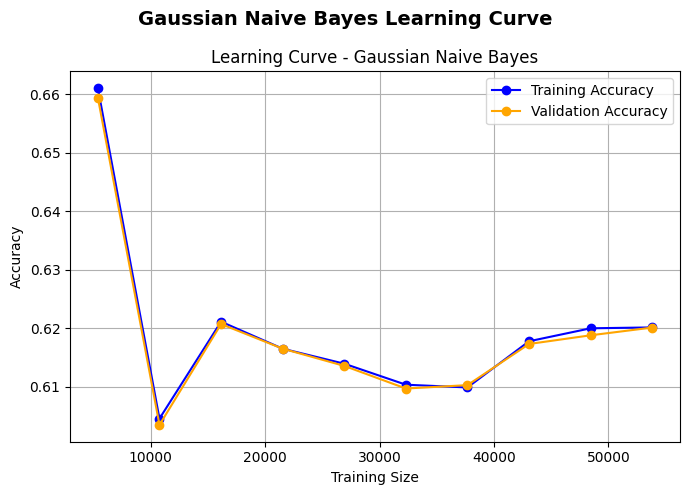

In [ ]:
plot_learning_curve(nb_model, "Gaussian Naive Bayes", X_train_processed, y_train)
plt.show()

## Adaboost Model
AdaBoost was used as a **boosting** ensemble algorithm. It trains weak learners sequentially, where each new learner focuses more on the samples that were previously misclassified. This helps improve overall classification performance.

In [ ]:
param_grid_ada = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

ada = AdaBoostClassifier(random_state=42)

grid_search_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_ada.fit(X_train_smote, y_train_smote)

print("Best AdaBoost Parameters:")
print(grid_search_ada.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search_ada.best_score_, 4))


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best AdaBoost Parameters:
{'learning_rate': 1.0, 'n_estimators': 150}

Best Cross Validation F1 Score:
0.913


In [ ]:
best_params_ada = grid_search_ada.best_params_

ada_best = AdaBoostClassifier(
    n_estimators=best_params_ada["n_estimators"],
    learning_rate=best_params_ada["learning_rate"],
    random_state=42
)

The best parameters found using GridSearchCV were used to retrain the final AdaBoost model before evaluation.

### Adaboost Results (Using best model)

The Random Forest model was evaluated using validation and test datasets. Performance was measured using Accuracy, Precision, Recall (Sensitivity), and F1-score in addition to the confusion matrix to better analyze classification performance on both diabetic and non-diabetic cases.

--- AdaBoost Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.9308,0.9270,0.9337
Precision,0.9175,0.5584,0.5860
Recall/Sensitivity,0.9140,0.8264,0.8467
F1 Score,0.9158,0.6665,0.6926



--- AdaBoost Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     13149
           1       0.56      0.83      0.67      1273

    accuracy                           0.93     14422
   macro avg       0.77      0.88      0.81     14422
weighted avg       0.94      0.93      0.93     14422



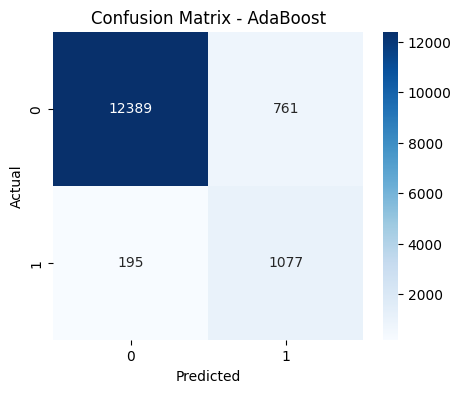

In [ ]:
ada_results = evaluate_model(
    model_name="AdaBoost",
    model=ada_best,
    X_train_data=X_train_smote,
    y_train_data=y_train_smote,
    X_val_data=X_val_processed,
    y_val_data=y_val,
    X_test_data=X_test_processed,
    y_test_data=y_test
)

Adaboost Learning Curve

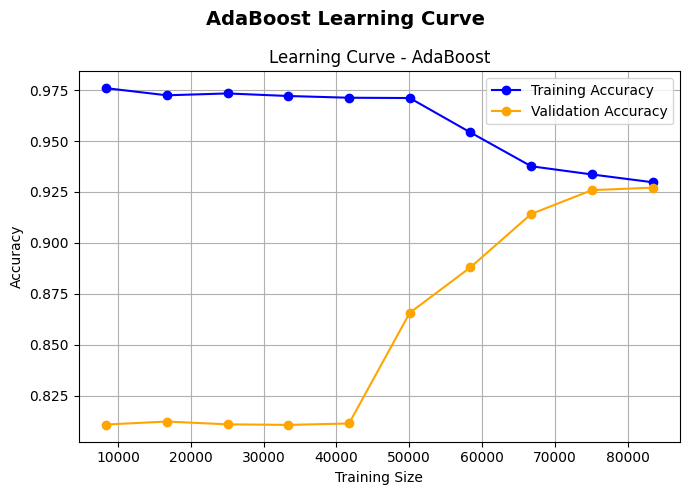

In [ ]:
plot_learning_curve(
    ada_best,
    "AdaBoost",
    X_train_smote,
    y_train_smote
)

## Random Forest Model



Random Forest was used as an ensemble learning model. It builds multiple decision trees and combines their predictions, which usually makes it more stable than a single decision tree. This model is useful because it can capture non-linear relationships between the diabetes features.(**BAGGING**)

In [ ]:
param_grid_rf = {
    "n_estimators": [50, 100],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_smote, y_train_smote)

print("Best Random Forest Parameters:")
print(grid_search_rf.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search_rf.best_score_, 4))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation F1 Score:
0.961


The best Random Forest parameters obtained from GridSearchCV were used to retrain the final model before evaluation.

### Random Forest Results

The AdaBoost model was evaluated using the same evaluation metrics to compare its performance against Random Forest and Naive Bayes. The confusion matrix was also used to analyze false positives and false negatives, especially for diabetic cases.

In [ ]:
best_params_rf = grid_search_rf.best_params_

rf_best = RandomForestClassifier(
    n_estimators=best_params_rf["n_estimators"],
    max_depth=best_params_rf["max_depth"],
    min_samples_split=best_params_rf["min_samples_split"],
    min_samples_leaf=best_params_rf["min_samples_leaf"],
    random_state=42
)

--- Random Forest Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.9992,0.9553,0.9601
Precision,0.9992,0.7625,0.7852
Recall/Sensitivity,0.9988,0.7164,0.7531
F1 Score,0.9990,0.7388,0.7689



--- Random Forest Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.98      0.98     13149
           1       0.76      0.72      0.74      1273

    accuracy                           0.96     14422
   macro avg       0.87      0.85      0.86     14422
weighted avg       0.95      0.96      0.95     14422



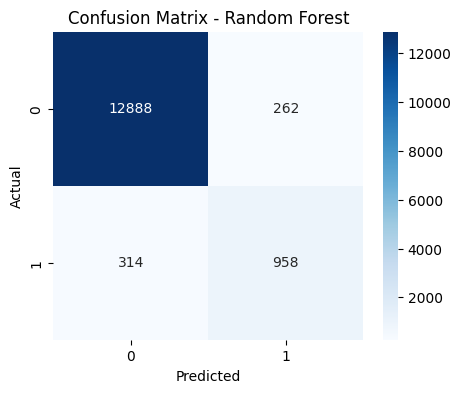

In [ ]:
rf_results = evaluate_model(
    model_name="Random Forest",
    model=rf_best,
    X_train_data=X_train_smote,
    y_train_data=y_train_smote,
    X_val_data=X_val_processed,
    y_val_data=y_val,
    X_test_data=X_test_processed,
    y_test_data=y_test
)

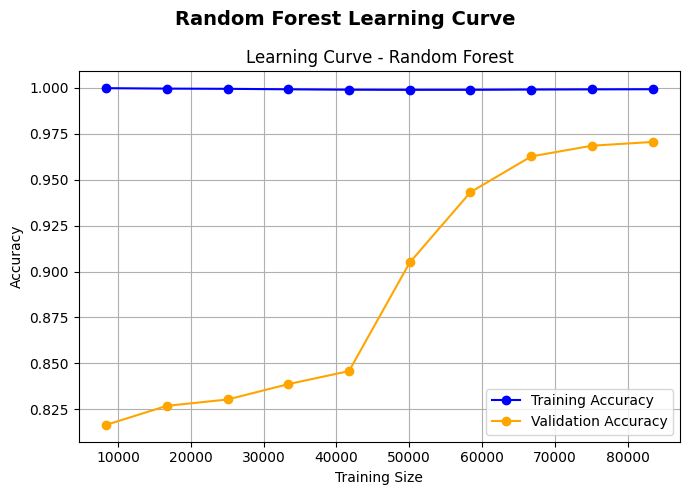

In [ ]:
plot_learning_curve(
    rf_best,
    "Random Forest",
    X_train_smote,
    y_train_smote
)

## XGBoost Model

In [ ]:
param_grid_xgb = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_smote, y_train_smote)

print("Best XGBoost Parameters:")
print(grid_search_xgb.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search_xgb.best_score_, 4))

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

Best Cross Validation F1 Score:
0.9492


### XGBoost Results

In [ ]:
best_params_xgb = grid_search_xgb.best_params_

xgb_best = XGBClassifier(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    random_state=42,
    eval_metric="logloss"
)

--- XGBoost Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.9629,0.9630,0.9668
Precision,0.9797,0.8261,0.8493
Recall/Sensitivity,0.9292,0.7353,0.7579
F1 Score,0.9538,0.7781,0.8010



--- XGBoost Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13149
           1       0.83      0.74      0.78      1273

    accuracy                           0.96     14422
   macro avg       0.90      0.86      0.88     14422
weighted avg       0.96      0.96      0.96     14422



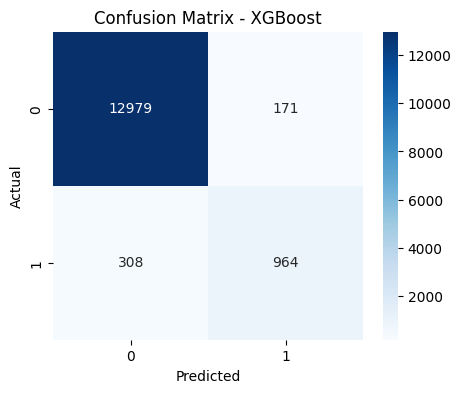

In [ ]:
xgb_results = evaluate_model(
    model_name="XGBoost",
    model=xgb_best,
    X_train_data=X_train_smote,
    y_train_data=y_train_smote,
    X_val_data=X_val_processed,
    y_val_data=y_val,
    X_test_data=X_test_processed,
    y_test_data=y_test
)

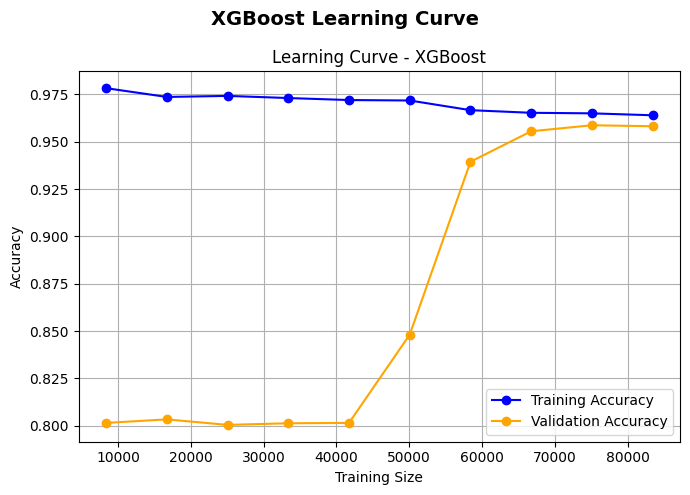

In [ ]:
plot_learning_curve(
    xgb_best,
    "XGBoost",
    X_train_smote,
    y_train_smote
)

## SVM

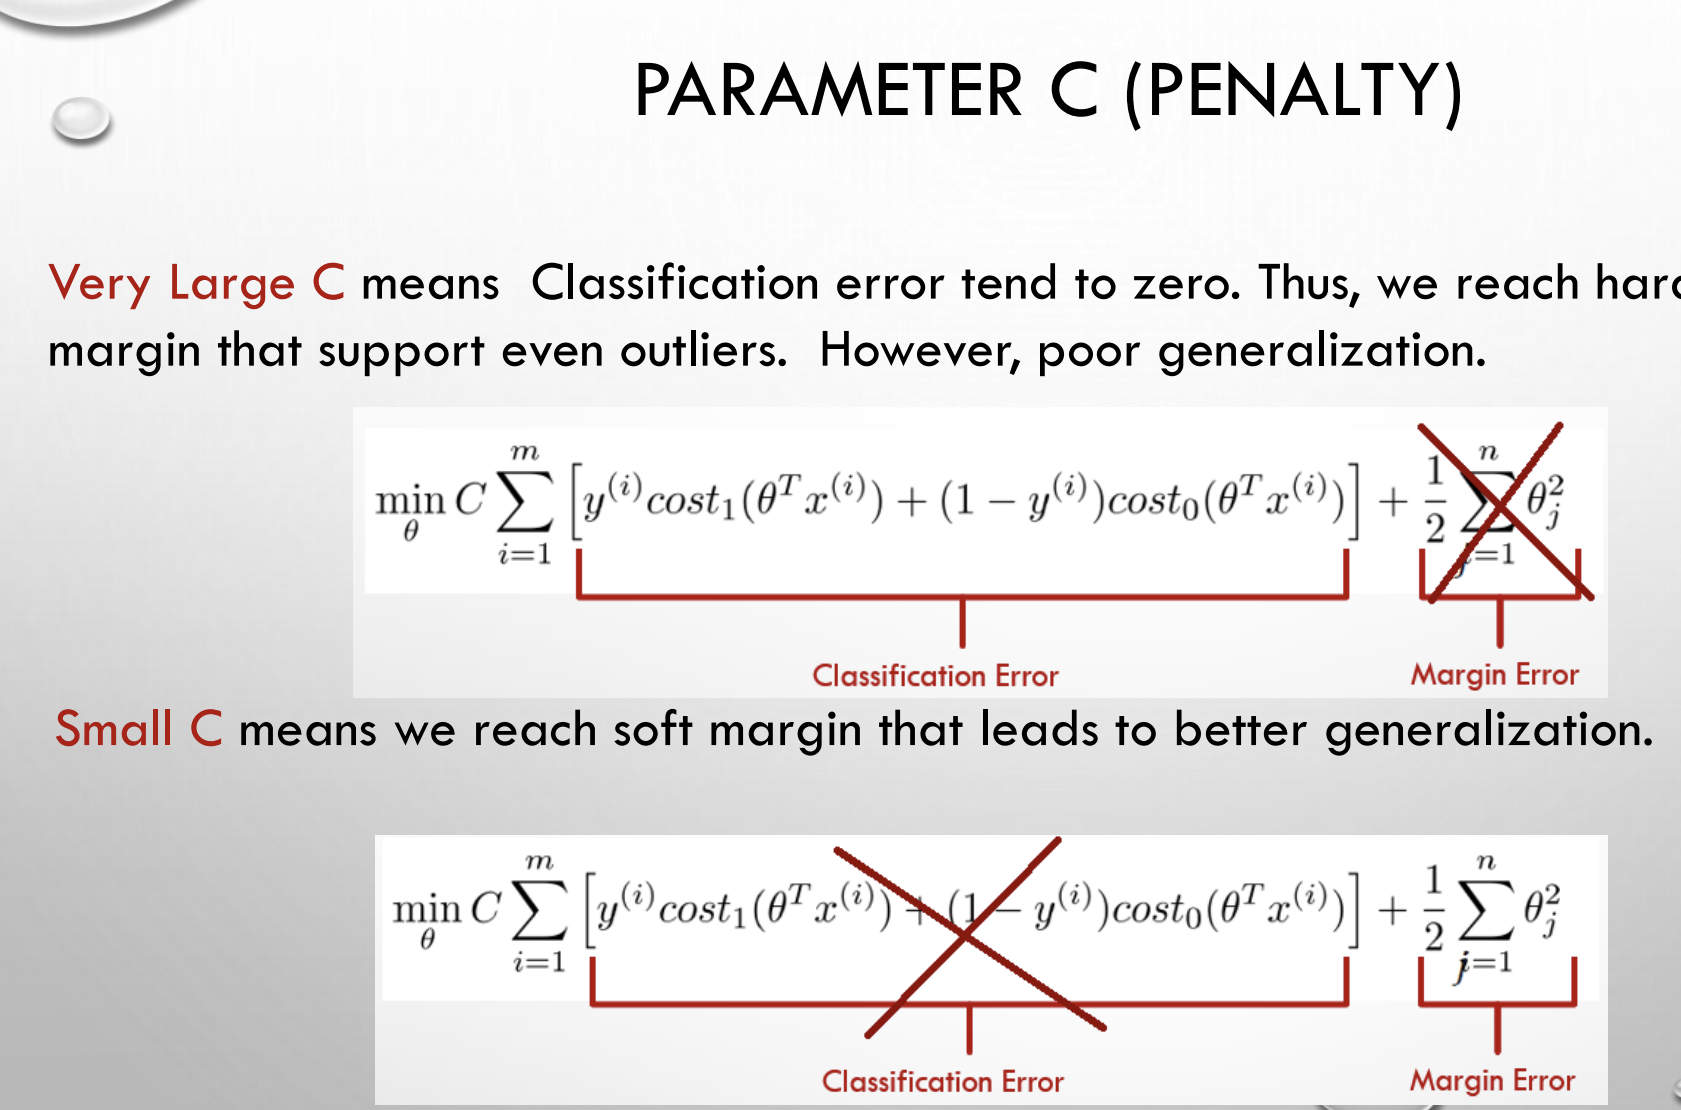



**Small C:**

Wider margin
More tolerance for mistakes

**Large C:**

Narrow margin
Aggressively fits training data

**Grid Search for Best Hyperparameters**

In [ ]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [1, 10, 50, 100],
    'gamma': [0.001, 0.01, 0.1],
    'degree': [2, 3, 4]
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=SVC(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Train on PCA data
random_search.fit(X_train_pca, y_train)

# Best parameters
print("Best Params (Randomized Search):")
print(random_search.best_params_)

# Best CV accuracy
print("\nBest Cross-Validation Accuracy:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params (Randomized Search):
{'kernel': 'rbf', 'gamma': 0.1, 'degree': 4, 'C': 100}

Best Cross-Validation Accuracy:
0.9670589284122314


### Generic PSO Fitness Function

In [ ]:
# Smaller subset ONLY for hyperparameter optimization
X_opt, _, y_opt, _ = train_test_split(
    X_train_pca,
    y_train,
    train_size=20000,
    stratify=y_train,
    random_state=42
)

print("Optimization subset shape:", X_opt.shape)

Optimization subset shape: (20000, 8)


In [ ]:
def svm_fitness(params, kernel):

    # LINEAR KERNEL
    if kernel == 'linear':

        logC = params[0]

        C = 10 ** logC

        model = LinearSVC(
            C=C,
            random_state=42,
            max_iter=5000
        )

    # RBF KERNEL
    elif kernel == 'rbf':

        logC, logGamma = params

        C = 10 ** logC
        gamma = 10 ** logGamma

        model = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma,
            cache_size=300,
            random_state=42
        )

    # POLYNOMIAL KERNEL
    elif kernel == 'poly':

        logC, degree = params

        C = 10 ** logC
        degree = int(round(degree))

        model = SVC(
            kernel='poly',
            C=C,
            degree=degree,
            gamma='scale',
            cache_size=300,
            random_state=42
    )

    # CROSS VALIDATION ON OPTIMIZATION SUBSET
    scores = cross_val_score(
        model,
        X_opt,
        y_opt,
        cv=3,
        scoring='accuracy',
        n_jobs=1
    )

    return -scores.mean()

Linear SVM only has ONE parameter being optimized --> C

**Linear Kernel PSO**

In [ ]:
print("\nRunning PSO for LINEAR kernel...")

best_linear_params, best_linear_score = pso(
    lambda params: svm_fitness(params, 'linear'),
    lb=[-2],        # log10(C)
    ub=[3],
    swarmsize=10,
    maxiter=10
)

best_linear_C = 10 ** best_linear_params[0]

print("\n--- Linear Kernel Results ---")
print("Best C:", best_linear_C)
print("Best CV Accuracy:", -best_linear_score)




Running PSO for LINEAR kernel...
Stopping search: maximum iterations reached --> 10

--- Linear Kernel Results ---
Best C: 41.60070382674036
Best CV Accuracy: 0.9584998622856137


**RBF Kernel Pso**

In [ ]:
print("\nRunning PSO for RBF kernel...")

best_rbf_params, best_rbf_score = pso(
    lambda params: svm_fitness(params, 'rbf'),

    # log10(C), log10(gamma)
    lb=[-1, -4],
    ub=[2, -1],

    swarmsize=5,
    maxiter=5
)

best_rbf_C = 10 ** best_rbf_params[0]
best_rbf_gamma = 10 ** best_rbf_params[1]

print("\n--- RBF Kernel Results ---")
print("Best C:", best_rbf_C)
print("Best gamma:", best_rbf_gamma)
print("Best CV Accuracy:", -best_rbf_score)


Running PSO for RBF kernel...
Stopping search: maximum iterations reached --> 5

--- RBF Kernel Results ---
Best C: 64.18944767235634
Best gamma: 0.1
Best CV Accuracy: 0.9640998448127398


**Poly kernel PSO**

In [ ]:
print("\nRunning PSO for POLY kernel...")

best_poly_params, best_poly_score = pso(
    lambda params: svm_fitness(params, 'poly'),

    lb=[-1, 2],
    ub=[2, 3],

    swarmsize=3,
    maxiter=3
)

best_poly_C = 10 ** best_poly_params[0]
best_poly_degree = int(round(best_poly_params[1]))

print("\n--- Polynomial Kernel Results ---")
print("Best C:", best_poly_C)
print("Best degree:", best_poly_degree)
print("Best CV Accuracy:", -best_poly_score)


Running PSO for POLY kernel...
Stopping search: maximum iterations reached --> 3

--- Polynomial Kernel Results ---
Best C: 4.100555119257807
Best degree: 3
Best CV Accuracy: 0.9624498298037394


In [ ]:
print("FINAL KERNEL COMPARISON")

print(f"Linear Accuracy : {-best_linear_score:.4f}")
print(f"RBF Accuracy    : {-best_rbf_score:.4f}")
print(f"Poly Accuracy   : {-best_poly_score:.4f}")

scores = {
    'linear': -best_linear_score,
    'rbf': -best_rbf_score,
    'poly': -best_poly_score
}

best_kernel = max(scores, key=scores.get)

print("\nBest Kernel Overall:", best_kernel)
print("Best Accuracy:", scores[best_kernel])

FINAL KERNEL COMPARISON
Linear Accuracy : 0.9585
RBF Accuracy    : 0.9641
Poly Accuracy   : 0.9624

Best Kernel Overall: rbf
Best Accuracy: 0.9640998448127398


PSO best kernel --> Polynomial of accuracy --> **0.9644**

Randomized search best kernel --> RBF of accuracy --> **0.96706**

**0.96706 > 0.9644**

**Train model using RBF, Gamma = 0.1, C = 100**


--- Final RBF SVM Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.9687,0.9650,0.9692
Precision,0.9913,0.9800,0.9814
Recall/Sensitivity,0.6512,0.6159,0.6635
F1 Score,0.7860,0.7564,0.7917



--- Final RBF SVM Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     13149
           1       0.98      0.62      0.76      1273

    accuracy                           0.96     14422
   macro avg       0.97      0.81      0.87     14422
weighted avg       0.97      0.96      0.96     14422



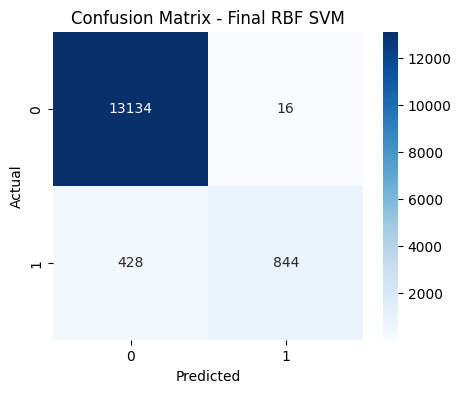

In [ ]:
final_rbf_model = SVC(
    kernel='rbf',
    C=100,
    gamma=0.1,
    cache_size=300,
    random_state=42
)

# evaluate model
rbf_results = evaluate_model(
    model_name="Final RBF SVM",
    model=final_rbf_model,
    X_train_data=X_train_pca,
    y_train_data=y_train,
    X_val_data=X_val_pca,
    y_val_data=y_val,
    X_test_data=X_test_pca,
    y_test_data=y_test
)


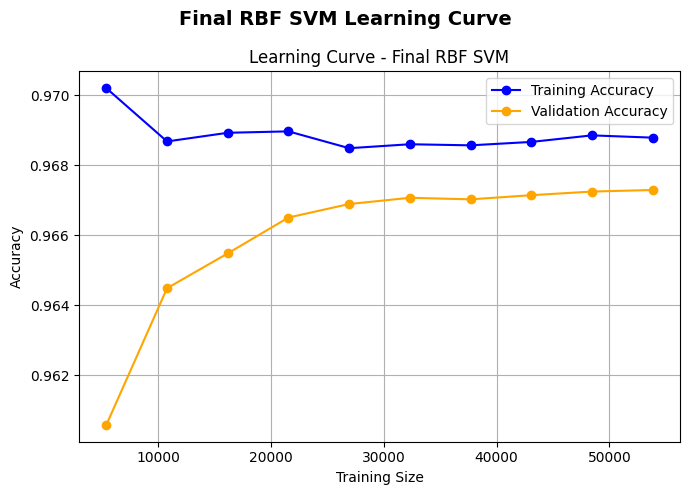


Final Model Results:
{'Model': 'Final RBF SVM', 'Training Accuracy': 0.968723069150991, 'Validation Accuracy': 0.96498405214256, 'Testing Accuracy': 0.9692137012896963, 'Training Precision': 0.9912820512820513, 'Validation Precision': 0.98, 'Testing Precision': 0.9813953488372092, 'Training Recall/Sensitivity': 0.651170624894728, 'Validation Recall/Sensitivity': 0.6158680282796544, 'Testing Recall/Sensitivity': 0.6635220125786163, 'Training F1 Score': 0.7860119955270916, 'Validation F1 Score': 0.7563917028461168, 'Testing F1 Score': 0.7917448405253283}


In [ ]:
#Learning curve
plot_learning_curve(
    model=final_rbf_model,
    model_name="Final RBF SVM",
    X_train_data=X_train_pca,
    y_train_data=y_train
)

print("\nFinal Model Results:")
print(rbf_results)

# Models Comparison Table

In [ ]:
all_model_results = [
    lr_results,
    mlp_results,
    nb_results,
    ada_results,
    rf_results,
    xgb_results,
    rbf_results
]

comparison_df = pd.DataFrame(all_model_results)


## Accuracy

In [ ]:
accuracy_df = comparison_df[['Model', 'Training Accuracy', 'Validation Accuracy', 'Testing Accuracy']].sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)
display(accuracy_df)

,Model,Training Accuracy,Validation Accuracy,Testing Accuracy
0,Final RBF SVM,0.968723,0.964984,0.969214
1,XGBoost,0.962922,0.962973,0.966787
2,Random Forest,0.999176,0.955277,0.960061
3,AdaBoost,0.930771,0.926987,0.933712
4,MLP,0.911944,0.912911,0.918111
5,Logistic Regression,0.887951,0.879975,0.885522
6,Gaussian Naive Bayes,0.619521,0.610456,0.622729


## Precision

In [ ]:
precision_df = comparison_df[['Model', 'Training Precision', 'Validation Precision', 'Testing Precision']].sort_values(by='Validation Precision', ascending=False).reset_index(drop=True)
display(precision_df)

,Model,Training Precision,Validation Precision,Testing Precision
0,Final RBF SVM,0.991282,0.980000,0.981395
1,XGBoost,0.979701,0.826125,0.849339
2,Random Forest,0.999231,0.762542,0.785246
3,AdaBoost,0.917529,0.558386,0.585963
4,MLP,0.892745,0.503912,0.521292
5,Logistic Regression,0.846707,0.414807,0.427644
6,Gaussian Naive Bayes,0.185340,0.180280,0.185738


## Recall/Sensitivity

In [ ]:
recall_df = comparison_df[['Model', 'Training Recall/Sensitivity', 'Validation Recall/Sensitivity', 'Testing Recall/Sensitivity']].sort_values(by='Validation Recall/Sensitivity', ascending=False).reset_index(drop=True)
display(recall_df)

,Model,Training Recall/Sensitivity,Validation Recall/Sensitivity,Testing Recall/Sensitivity
0,Gaussian Naive Bayes,0.975745,0.962294,0.968553
1,Logistic Regression,0.888791,0.875884,0.880503
2,MLP,0.893493,0.860173,0.875786
3,AdaBoost,0.914026,0.826394,0.846698
4,XGBoost,0.929205,0.735271,0.757862
5,Random Forest,0.998766,0.716418,0.753145
6,Final RBF SVM,0.651171,0.615868,0.663522


## F1 Score

In [ ]:
f1_df = comparison_df[['Model', 'Training F1 Score', 'Validation F1 Score', 'Testing F1 Score']].sort_values(by='Validation F1 Score', ascending=False).reset_index(drop=True)
display(f1_df)
#a

,Model,Training F1 Score,Validation F1 Score,Testing F1 Score
0,XGBoost,0.953785,0.778055,0.800997
1,Final RBF SVM,0.786012,0.756392,0.791745
2,Random Forest,0.998999,0.738761,0.768860
3,AdaBoost,0.915774,0.666455,0.692605
4,MLP,0.893119,0.635519,0.653564
5,Logistic Regression,0.867238,0.562989,0.575687
6,Gaussian Naive Bayes,0.311510,0.303669,0.311701


# Best Model with PCA
Based on F1 Score

## Apply PCA On SMOTE Data

In [ ]:
print("Applying PCA to SMOTE-transformed training data and original validation/test data...")

# Apply PCA to the SMOTE-transformed training data and the original validation/test processed data
X_train_smote_pca, X_val_smote_pca, X_test_smote_pca, pca_model_smote = apply_pca(
    X_train_smote, # SMOTEd preprocessed data for PCA fitting
    X_val_processed, # Original preprocessed validation data for transformation
    X_test_processed, # Original preprocessed test data for transformation
    n_components=0.95
)

print("X_train_smote_pca shape:", X_train_smote_pca.shape)
print("X_val_smote_pca shape:", X_val_smote_pca.shape)
print("X_test_smote_pca shape:", X_test_smote_pca.shape)


Applying PCA to SMOTE-transformed training data and original validation/test data...
Original features: 14
PCA features: 8
Explained variance: 0.9754
X_train_smote_pca shape: (104320, 8)
X_val_smote_pca shape: (14422, 8)
X_test_smote_pca shape: (14422, 8)


## Evaluate Model with Best Hyperparameters

--- XGBoost (SMOTE then PCA) Model Evaluation ---


,Training,Validation,Testing
Metric,,,
Accuracy,0.9122,0.9090,0.9173
Precision,0.8906,0.4912,0.5184
Recall/Sensitivity,0.8968,0.8594,0.8742
F1 Score,0.8937,0.6251,0.6509



--- XGBoost (SMOTE then PCA) Validation Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     13149
           1       0.49      0.86      0.63      1273

    accuracy                           0.91     14422
   macro avg       0.74      0.89      0.79     14422
weighted avg       0.94      0.91      0.92     14422



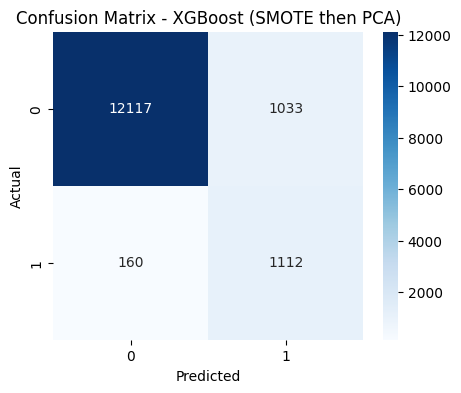

In [ ]:
# Retrieve best hyperparameters for XGBoost
best_params_xgb = grid_search_xgb.best_params_

# Instantiate XGBoost model with best parameters
xgb_smote_pca_model = XGBClassifier(
    n_estimators=best_params_xgb["n_estimators"],
    max_depth=best_params_xgb["max_depth"],
    learning_rate=best_params_xgb["learning_rate"],
    subsample=best_params_xgb["subsample"],
    random_state=42,
    eval_metric="logloss"
)

# Evaluate the XGBoost model using SMOTE -> PCA data
xgb_smote_pca_results = evaluate_model(
    model_name="XGBoost (SMOTE then PCA)",
    model=xgb_smote_pca_model,
    X_train_data=X_train_smote_pca,
    y_train_data=y_train_smote, # Use y_train_smote as it corresponds to X_train_smote
    X_val_data=X_val_smote_pca,
    y_val_data=y_val,
    X_test_data=X_test_smote_pca,
    y_test_data=y_test
)

## Plot learning curve for XGBoost with SMOTE -> PCA data

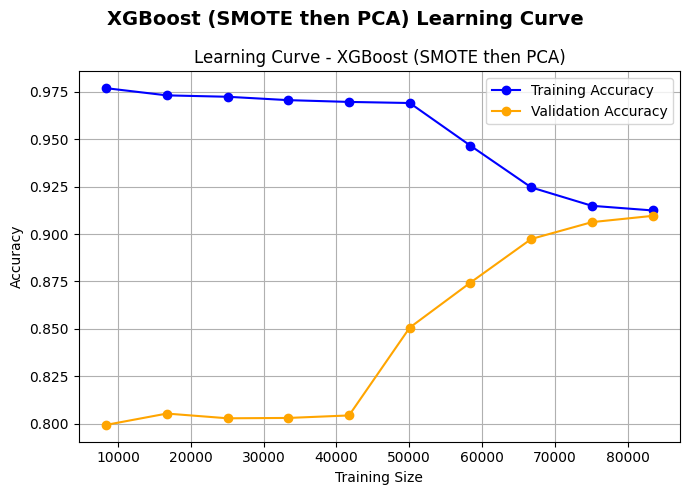

In [ ]:
plot_learning_curve(
    xgb_smote_pca_model,
    "XGBoost (SMOTE then PCA)",
    X_train_smote_pca,
    y_train_smote
)

## Add results to the comparison table

In [ ]:
all_model_results.append(xgb_smote_pca_results)
comparison_df = pd.DataFrame(all_model_results)

print("\nUpdated Accuracy Comparison:")
accuracy_df = comparison_df[['Model', 'Training Accuracy', 'Validation Accuracy', 'Testing Accuracy']].sort_values(by='Validation Accuracy', ascending=False).reset_index(drop=True)
display(accuracy_df)

print("\nUpdated Precision Comparison:")
precision_df = comparison_df[['Model', 'Training Precision', 'Validation Precision', 'Testing Precision']].sort_values(by='Validation Precision', ascending=False).reset_index(drop=True)
display(precision_df)

print("\nUpdated Recall/Sensitivity Comparison:")
recall_df = comparison_df[['Model', 'Training Recall/Sensitivity', 'Validation Recall/Sensitivity', 'Testing Recall/Sensitivity']].sort_values(by='Validation Recall/Sensitivity', ascending=False).reset_index(drop=True)
display(recall_df)

print("\nUpdated F1 Score Comparison:")
f1_df = comparison_df[['Model', 'Training F1 Score', 'Validation F1 Score', 'Testing F1 Score']].sort_values(by='Validation F1 Score', ascending=False).reset_index(drop=True)
display(f1_df)


Updated Accuracy Comparison:


,Model,Training Accuracy,Validation Accuracy,Testing Accuracy
0,Final RBF SVM,0.968723,0.964984,0.969214
1,XGBoost,0.962922,0.962973,0.966787
2,Random Forest,0.999176,0.955277,0.960061
3,AdaBoost,0.930771,0.926987,0.933712
4,MLP,0.911944,0.912911,0.918111
5,XGBoost (SMOTE then PCA),0.912155,0.909028,0.917279
6,Logistic Regression,0.887951,0.879975,0.885522
7,Gaussian Naive Bayes,0.619521,0.610456,0.622729



Updated Precision Comparison:


,Model,Training Precision,Validation Precision,Testing Precision
0,Final RBF SVM,0.991282,0.980000,0.981395
1,XGBoost,0.979701,0.826125,0.849339
2,Random Forest,0.999231,0.762542,0.785246
3,AdaBoost,0.917529,0.558386,0.585963
4,MLP,0.892745,0.503912,0.521292
5,XGBoost (SMOTE then PCA),0.890584,0.491244,0.518415
6,Logistic Regression,0.846707,0.414807,0.427644
7,Gaussian Naive Bayes,0.185340,0.180280,0.185738



Updated Recall/Sensitivity Comparison:


,Model,Training Recall/Sensitivity,Validation Recall/Sensitivity,Testing Recall/Sensitivity
0,Gaussian Naive Bayes,0.975745,0.962294,0.968553
1,Logistic Regression,0.888791,0.875884,0.880503
2,MLP,0.893493,0.860173,0.875786
3,XGBoost (SMOTE then PCA),0.896846,0.859387,0.874214
4,AdaBoost,0.914026,0.826394,0.846698
5,XGBoost,0.929205,0.735271,0.757862
6,Random Forest,0.998766,0.716418,0.753145
7,Final RBF SVM,0.651171,0.615868,0.663522



Updated F1 Score Comparison:


,Model,Training F1 Score,Validation F1 Score,Testing F1 Score
0,XGBoost,0.953785,0.778055,0.800997
1,Final RBF SVM,0.786012,0.756392,0.791745
2,Random Forest,0.998999,0.738761,0.768860
3,AdaBoost,0.915774,0.666455,0.692605
4,MLP,0.893119,0.635519,0.653564
5,XGBoost (SMOTE then PCA),0.893704,0.625143,0.650863
6,Logistic Regression,0.867238,0.562989,0.575687
7,Gaussian Naive Bayes,0.311510,0.303669,0.311701
